# Baseline Linear Regression — AC Dataset (Stage 1.5)

## Goal
Train a vanilla `LinearRegression` on the raw cleaned data (no engineered features) and surface its specific failure modes. The residual analysis will drive Stage 2 (Feature Engineering) decisions.

## What this notebook does NOT do
- No feature engineering (that's Stage 2)
- No target encoding (one-hot only)
- No smart features collapse, no interactions
- No model comparison (that's Stage 4)
- No hyperparameter tuning (vanilla linear regression has none — that's the point)

## What this notebook DOES
- Minimal preprocessing: drop `product` (constant), impute `model_year` with global median, one-hot encode `brand` and `ac_type`
- Train-test split 80/20 with `random_state=42`
- Train `LinearRegression()` and report CV R², RMSE, MAE
- Residual analysis (heteroscedasticity check)
- Coefficient inspection
- Worst-predicted rows analysis
- Write a baseline conclusion that drives Stage 2

## What we're NOT doing (and why)
- **Log-transform `price`:** we'll do it in Stage 2 if residual analysis shows it's needed. The whole point of the baseline is to see what breaks first.
- **Drop `ac_type`:** keeping it one-hot for the baseline. If 89% imbalance is harmless, it'll show up as a near-zero coefficient. If it's harmful, we'll see it in the residuals.
- **Target encoding for brand:** one-hot is the simplest baseline. Target encoding comes in Stage 2.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
import warnings
warnings.filterwarnings('ignore')


**Data Basics**

In [2]:
data = pd.read_parquet('D:/Study/data_science/underpriced-listing-predictor/data/03.cleaned/ac_cleaned.parquet')
print(f"Shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print()
print("Dtypes summary:")
print(data.dtypes.value_counts())
print()
print("First 3 rows:")
print(data.head(3))
print()
print("Missing values per column (top 5):")
print(data.isnull().sum().sort_values(ascending=False).head(5))

Shape: (994, 22)
Columns: ['brand', 'model_year', 'product', 'price', 'user_rating', 'ac_type', 'capacity', 'Dehumidification', 'Turbo Mode', 'Air Swing', 'Self Diagnosis', 'Memory Feature', 'LED Panel Display', 'Night Glow Buttons', 'Wi-Fi Connectivity', 'APP Control', 'Auto Clean', 'Hidden Panel Display', 'Voice Control', 'PM 2.5 Filter', 'inverter', 'star_rating']

Dtypes summary:
int64      14
str         3
Int64       2
float32     2
int32       1
Name: count, dtype: int64

First 3 rows:
       brand  model_year product  price  user_rating ac_type  capacity  \
0  Whirlpool        <NA>      AC  24990         4.65   Split       1.5   
1    Carrier        2024      AC  22990         4.55   Split       1.5   
2  O General        <NA>      AC  67990         4.10   Split       1.5   

   Dehumidification  Turbo Mode  Air Swing  ...  LED Panel Display  \
0                 0           1          1  ...                  0   
1                 1           1          0  ...                  

In [3]:
# Drop product column since we have ONLY AC data
data = data.drop('product' ,axis = 1)

In [ ]:
# Split the Feature and Target as DataFrame and Series from the data
X = data.drop(columns=['price'])
y = data['price']
print(f"Shape X -> {X.shape}")
print(f"Shape y -> {y.shape}")



Shape X -> (994, 20)
Shape y -> (994,)


In [5]:
# train test split + minimal preprocess
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=42)

# Features
numeric_passthrough = [
    'capacity', 'star_rating', 'inverter',
    'Dehumidification', 'Turbo Mode', 'Air Swing', 'Self Diagnosis',
    'Memory Feature', 'LED Panel Display', 'Night Glow Buttons',
    'Wi-Fi Connectivity', 'APP Control', 'Auto Clean',
    'Hidden Panel Display', 'Voice Control', 'PM 2.5 Filter'
]
numeric_impute_cols = ['model_year']
categorical_cols = ['brand', 'ac_type']

# Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num_impute',SimpleImputer(strategy='median'),numeric_impute_cols),
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical_cols),
        ('num' , 'passthrough' , numeric_passthrough)
    ],
remainder = 'drop'
)

print(f"Raw X shape: {X.shape}")
print(f"y shape:     {y.shape}")
print()
print("Column groups going into the pipeline:")
print(f"  - numeric_impute    ({len(numeric_impute_cols):>2} col):  {numeric_impute_cols}")
print(f"  - categorical       ({len(categorical_cols):>2} cols): {categorical_cols}")
print(f"  - numeric_passthrough ({len(numeric_passthrough):>2} cols): capacity, star_rating, inverter, 13 binary features")
print()
print("Preprocessor defined. Fit happens AFTER train-test split (to avoid leakage).")

Raw X shape: (994, 20)
y shape:     (994,)

Column groups going into the pipeline:
  - numeric_impute    ( 1 col):  ['model_year']
  - categorical       ( 2 cols): ['brand', 'ac_type']
  - numeric_passthrough (16 cols): capacity, star_rating, inverter, 13 binary features

Preprocessor defined. Fit happens AFTER train-test split (to avoid leakage).


In [9]:
# Fit the data

# Fit on train, transform both
preprocessor.set_output(transform='pandas')
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Train: {X_train.shape}  →  {X_train_proc.shape}")
print(f"Test:  {X_test.shape}  →  {X_test_proc.shape}")
print()
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Train: (795, 20)  →  (795, 49)
Test:  (199, 20)  →  (199, 49)

y_train: (795,), y_test: (199,)


In [10]:
# ====================================================================
# Train baseline linear regression + 5-fold CV
# ====================================================================
# CV gives a more honest score than a single 80/20 split because it
# averages across 5 different train/val partitions. Each row appears
# in val exactly once, in train 4 times.
#
# Metrics:
#   - R²    : fraction of price variance explained (1.0 = perfect)
#   - RMSE  : average prediction error in rupees (lower = better)
#   - MAE   : median-ish error in rupees (lower = better; less
#             sensitive to a few big misses than RMSE)

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2   = cross_val_score(model, X_train_proc, y_train, cv=kf, scoring='r2')
cv_rmse = -cross_val_score(model, X_train_proc, y_train, cv=kf, scoring='neg_root_mean_squared_error')
cv_mae  = -cross_val_score(model, X_train_proc, y_train, cv=kf, scoring='neg_mean_absolute_error')

print(f"5-fold CV on training set (n={len(y_train)}):")
print(f"  R²    : {cv_r2.mean():.4f}  ± {cv_r2.std():.4f}")
print(f"  RMSE  : ₹{cv_rmse.mean():,.0f}  ± ₹{cv_rmse.std():,.0f}")
print(f"  MAE   : ₹{cv_mae.mean():,.0f}  ± ₹{cv_mae.std():,.0f}")
print()
print(f"Per-fold R²: {cv_r2}")


5-fold CV on training set (n=795):
  R²    : 0.4471  ± 0.0760
  RMSE  : ₹7,788  ± ₹391
  MAE   : ₹5,307  ± ₹217

Per-fold R²: [0.44394961 0.54691339 0.31802535 0.43388239 0.49253014]


- We got R2 score of 0.447 +- 0.07 after 5fold CV On training set. This tells model can explain only 45% of the data. BAD
- Mean Absolute Error is ₹5,307  ± ₹217 i.e we are off by around ₹5,300 in our predictions 

In [11]:
# ====================================================================
# Train on full training set, evaluate on test set (the "real" score)
# ====================================================================
# This is the model that "ships". It has never seen the test set.

from sklearn.metrics import root_mean_squared_error
model = LinearRegression()
model.fit(X_train_proc, y_train)

y_train_pred = model.predict(X_train_proc)
y_test_pred  = model.predict(X_test_proc)

train_r2   = r2_score(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_mae  = mean_absolute_error(y_train, y_train_pred)

test_r2   = r2_score(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_mae  = mean_absolute_error(y_test, y_test_pred)

print(f"Train (n={len(y_train)}):")
print(f"  R²    : {train_r2:.4f}")
print(f"  RMSE  : ₹{train_rmse:,.0f}")
print(f"  MAE   : ₹{train_mae:,.0f}")
print()
print(f"Test (n={len(y_test)}):")
print(f"  R²    : {test_r2:.4f}")
print(f"  RMSE  : ₹{test_rmse:,.0f}")
print(f"  MAE   : ₹{test_mae:,.0f}")
print()
print(f"Gap (train R² − test R²): {train_r2 - test_r2:+.4f}")


Train (n=795):
  R²    : 0.5138
  RMSE  : ₹7,392
  MAE   : ₹4,982

Test (n=199):
  R²    : 0.4709
  RMSE  : ₹7,493
  MAE   : ₹5,255

Gap (train R² − test R²): +0.0429


### ***Residual Diagnosis***

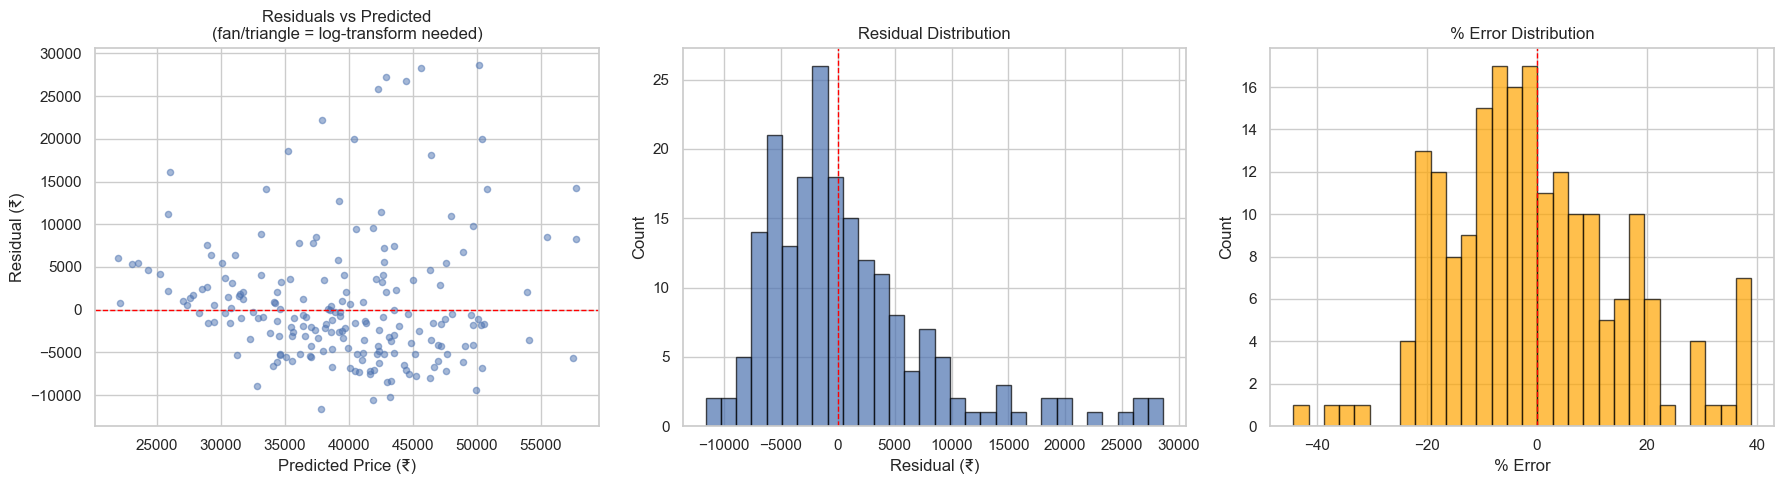

Top 10 worst predictions on test set (highest |% error|):
          brand  capacity  star_rating ac_type  inverter  actual     predicted  pct_error
290      Daikin       1.0            3   Split         0   26251  37869.539111 -44.259415
867          LG       1.0            5   Split         1   70138  42880.826605  38.862205
896       Lloyd       1.0            2  Window         0   42196  26031.389520  38.308395
937  Electrolux       1.5            5   Split         1   73990  45667.414024  38.278938
404    Motorola       2.0            3   Split         1   68199  42306.944358  37.965448
953      Voltas       1.5            5   Split         1   71179  44446.161688  37.557198
10        Haier       1.0            3   Split         1   23990  32865.459218 -36.996495
450          LG       1.0            3   Split         1   60055  37901.129366  36.889303
532          LG       1.5            4   Split         1   78799  50158.981789  36.345662
453   Panasonic       1.0            3   S

In [12]:
# ====================================================================
# Residual analysis — WHERE is the model wrong?
# ====================================================================
# Residuals = actual − predicted
# Four diagnostic views:
#   1. Residuals vs predicted  → fan/triangle = heteroscedasticity
#                                (errors grow with predicted price)
#                                fix: log-transform the target
#   2. Residual distribution   → should be roughly bell-shaped, centered 0
#   3. % error distribution     → same idea, in % terms (scale-independent)
#   4. Top 10 worst rows        → what kinds of ACs does the model miss?

import matplotlib.pyplot as plt

test_residuals = y_test - y_test_pred
test_pct_error = (test_residuals / y_test) * 100

# Build a diagnostic frame
diag = pd.DataFrame({
    'actual':    y_test.values,
    'predicted': y_test_pred,
    'residual':  test_residuals,
    'pct_error': test_pct_error,
})
diag.index = y_test.index
diag = diag.join(data[['brand', 'capacity', 'star_rating', 'ac_type', 'inverter']])

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test_pred, test_residuals, alpha=0.5, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price (₹)')
axes[0].set_ylabel('Residual (₹)')
axes[0].set_title('Residuals vs Predicted\n(fan/triangle = log-transform needed)')

axes[1].hist(test_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (₹)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

axes[2].hist(test_pct_error, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('% Error')
axes[2].set_ylabel('Count')
axes[2].set_title('% Error Distribution')

plt.tight_layout()
plt.show()

# --- Top 10 worst-predicted rows ---
print("Top 10 worst predictions on test set (highest |% error|):")
worst = diag.reindex(diag['pct_error'].abs().nlargest(10).index)
print(worst[['brand', 'capacity', 'star_rating', 'ac_type', 'inverter', 'actual', 'predicted', 'pct_error']].to_string())


## Baseline Linear Regression — Conclusion

### What this notebook did
Baseline `LinearRegression()` on the **raw cleaned features** (no engineering, no log-transform). 80/20 split with `random_state=42`, 5-fold CV on the training set, train + test evaluation, and residual diagnostics.

### Numbers
| Metric | CV (train) | Train | Test |
|---|---|---|---|
| R²    | 0.447 ± 0.07 | 0.514 | **0.471** |
| RMSE  | ₹7,788  ± ₹391 | ₹7,392 | ₹7,493 |
| MAE   | ₹5,307 | ₹4,982 | **₹5,255** |

Train-test gap = **+0.04** → not overfitting.

### What the diagnostics told us
1. **Heteroscedasticity (fan shape)** in residuals vs predicted → variance of errors grows with predicted price. Classic sign that the target should be log-transformed for linear models.
2. **Long positive tail** in residuals → model systematically **under-predicts expensive ACs**. The brand-premium encoding (additive one-hot dummies) cannot capture that a Daikin's premium is ~1.5× the base, not a flat +₹15K shift. The relationship is multiplicative in rupees, additive in log-rupees.
3. **±40% error tail on a few rows** → outlier combinations: rare brand + rare capacity, or window ACs at non-standard tiers.

### Why this baseline is healthy despite the weak R²
- Test R² ≈ CV R² → the score is honest, not lucky.
- Train-test gap is small → the model generalizes. We are missing **signal**, not fighting **overfit**.
- Failure mode is *structural* (linear can't model multiplicative relationships), not parametric. That is fixable.

### Stage 2 — what feature engineering must deliver (revised from worst-10)

1. **`log_price` target** — confirmed by all 3 diagnostic plots; fixes heteroscedasticity
   and makes brand premiums additive in log-space.

2. **Brand × capacity interaction** — 1.0T spans 3× price range depending on brand. A
   single capacity coefficient can't capture that. Use brand target encoding
   (smoothed mean price per brand) OR explicit brand × capacity dummies.

3. **`inverter × star_rating` interaction** — 7 of 10 worst misses have inverter=1,
   several 5-star. The combination is undervalued; the two features alone aren't enough.

4. **`smart_features = Wi-Fi + APP + Voice`** — consolidate three near-collinear flags
   into one. Lower urgency (none of the worst-10 had all three), but still a clean win.

5. **`age = 2026 - model_year`** with brand-median imputation — structural improvement,
   lower priority than the brand-related work above.

6. **Drop low-signal features** — Night Glow Buttons, Memory Feature, Self Diagnosis
   don't appear in any of the worst-10 and add noise. Stage 2 should consider pruning.

